# 03 · SA Deep Dive — Path Tracing, Schedules, and Stochastic SA

In this notebook we:

1. **Trace the path** SA takes on each landscape and visualise it on a contour map.
2. **Compare four cooling schedules** — how the choice of schedule dramatically affects the result.
3. **Compare SA vs. Stochastic SA (SSA)** — does reheating help on Ackley?
4. **Explore the temperature sensitivity** — what happens when initial T is too low or too high?

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

from simulated_annealing import SimulatedAnnealing, StochasticSA
from simulated_annealing.landscapes import LANDSCAPES, sphere, ackley, rosenbrock
from simulated_annealing.schedules import GeometricCooling, AdditiveCooling, LogarithmicCooling, SlowDecrease
from simulated_annealing.neighbours import GaussianStep, AdaptiveStep
from simulated_annealing.utils import (
    plot_path_on_contour, plot_temperature_schedule, plot_acceptance_probability
)

## 1  Path Tracing on All Three Landscapes

The path shows every **accepted** position.  Early steps (lighter colour) explore broadly; later steps (darker) converge.

In [2]:
def run_sa(fn, bounds, seed=0, initial_temp=10.0, final_temp=1e-4, alpha=0.97, scale=0.3):
    sa = SimulatedAnnealing(
        schedule=GeometricCooling(alpha=alpha),
        neighbourhood=GaussianStep(scale=scale, seed=seed),
        initial_temp=initial_temp,
        final_temp=final_temp,
    )
    return sa.optimize(fn, bounds=bounds)

# Sphere
r_sphere = run_sa(sphere, LANDSCAPES['sphere'].bounds)
print(f"Sphere:     f* = {r_sphere.value:.6f}  at {r_sphere.solution}")
print(f"            {len(r_sphere.path)} accepted steps, {r_sphere.n_evaluations} evals")

# Ackley — needs higher initial temp
r_ackley = run_sa(ackley, LANDSCAPES['ackley'].bounds, initial_temp=15.0, scale=0.5)
print(f"Ackley:     f* = {r_ackley.value:.6f}  at {r_ackley.solution}")

# Rosenbrock — narrow valley needs small steps
r_rosenbrock = run_sa(rosenbrock, LANDSCAPES['rosenbrock'].bounds, scale=0.15, alpha=0.99)
print(f"Rosenbrock: f* = {r_rosenbrock.value:.6f}  at {r_rosenbrock.solution}")

Sphere:     f* = 0.002419  at [-0.01709746 -0.04611877]
            124 accepted steps, 757 evals
Ackley:     f* = 0.268572  at [-0.05839059  0.01750812]
Rosenbrock: f* = 0.001236  at [1.00393791 1.00439832]


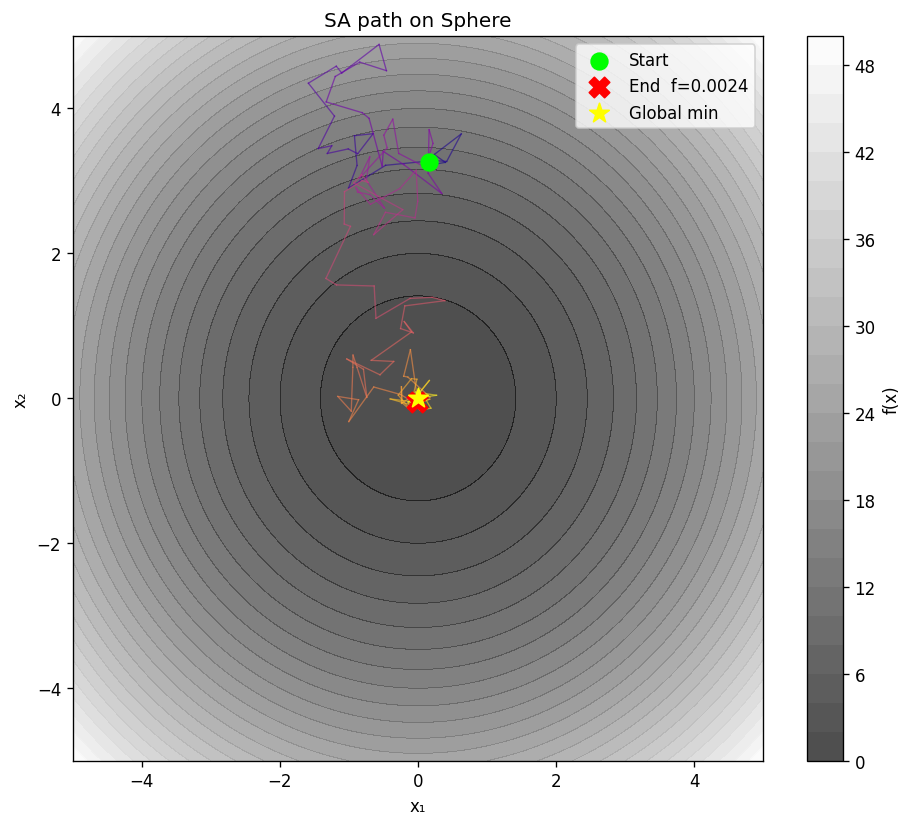

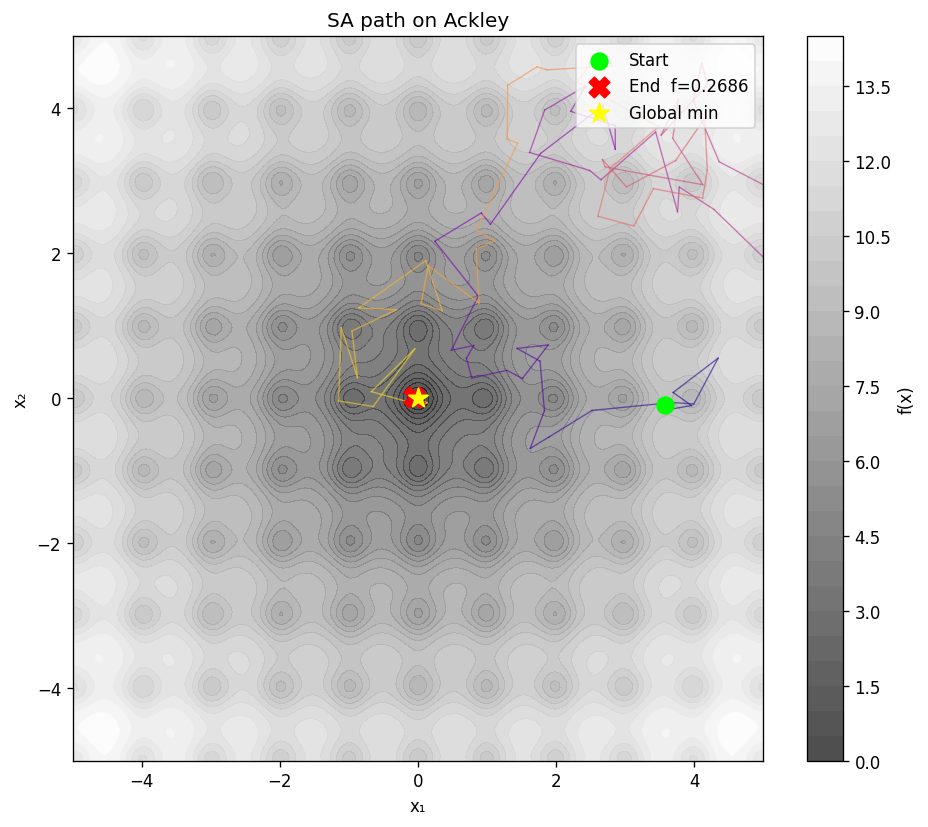

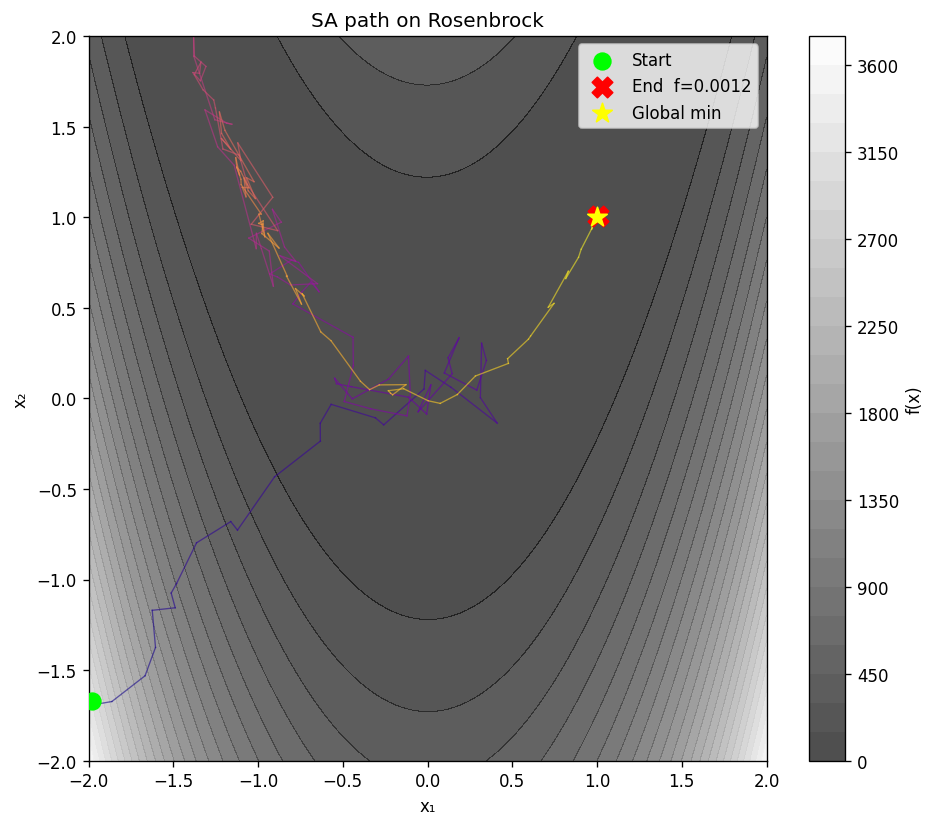

In [3]:
from simulated_annealing.utils.visualization import _make_grid

def plot_sa_path(fn, bounds, result, title, known_min, n_points=200, levels=30, max_pts=400):
    """Plot the SA path on a contour of the landscape."""
    X, Y, Z = _make_grid(fn, bounds, n_points)
    fig, ax = plt.subplots(figsize=(8, 7))
    cf = ax.contourf(X, Y, Z, levels=levels, cmap='gray', alpha=0.7)
    fig.colorbar(cf, ax=ax, label='f(x)')

    path = result.path
    if len(path) > max_pts:
        step = len(path) // max_pts
        path = path[::step]

    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    # Colour by step index
    colors = plt.cm.plasma(np.linspace(0, 1, len(xs)))
    for i in range(len(xs) - 1):
        ax.plot(xs[i:i+2], ys[i:i+2], '-', color=colors[i], alpha=0.6, linewidth=0.8)
    ax.scatter(xs[0], ys[0], color='lime', s=100, marker='o', zorder=6, label='Start')
    ax.scatter(result.solution[0], result.solution[1], color='red', s=150, marker='X', zorder=7, label=f'End  f={result.value:.4f}')
    ax.scatter(*known_min, color='yellow', s=150, marker='*', zorder=8, label='Global min')
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_title(title)
    ax.legend(loc='upper right')
    fig.tight_layout()
    return fig

fig = plot_sa_path(sphere, LANDSCAPES['sphere'].bounds, r_sphere, 'SA path on Sphere', [0,0])
plt.show()

fig = plot_sa_path(ackley, LANDSCAPES['ackley'].bounds, r_ackley, 'SA path on Ackley', [0,0])
plt.show()

fig = plot_sa_path(rosenbrock, LANDSCAPES['rosenbrock'].bounds, r_rosenbrock,
                   'SA path on Rosenbrock', [1,1])
plt.show()

## 2  Comparing Cooling Schedules

Let's first see how the four schedules differ in their decay curves, then run SA with each one on Ackley.

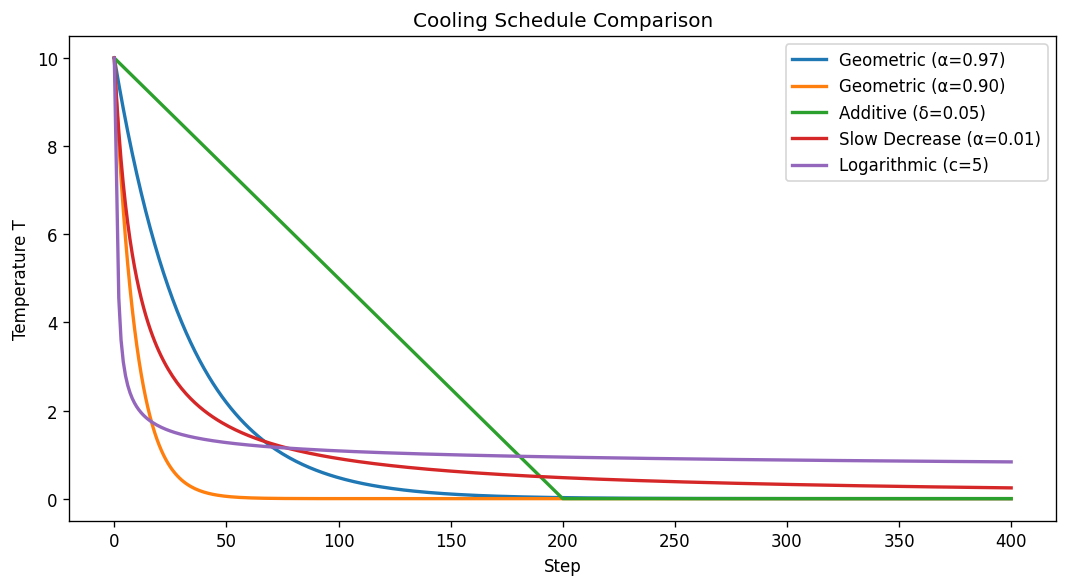

In [4]:
schedules = {
    'Geometric (α=0.97)':  GeometricCooling(alpha=0.97),
    'Geometric (α=0.90)':  GeometricCooling(alpha=0.90),
    'Additive (δ=0.05)':   AdditiveCooling(delta=0.05),
    'Slow Decrease (α=0.01)': SlowDecrease(alpha=0.01),
    'Logarithmic (c=5)':   LogarithmicCooling(c=5.0),
}
fig = plot_temperature_schedule(schedules, initial_temp=10.0, n_steps=400,
                                title='Cooling Schedule Comparison')
plt.show()

In [6]:
# Run SA on Ackley with each schedule
ackley_bounds = LANDSCAPES['ackley'].bounds
results_by_schedule = {}

schedule_configs = {
    'Geometric α=0.97': GeometricCooling(alpha=0.97),
    'Geometric α=0.90': GeometricCooling(alpha=0.90),
    'Slow Decrease':    SlowDecrease(alpha=0.01),
    # 'Logarithmic':      LogarithmicCooling(c=5.0),
}

for name, sched in schedule_configs.items():
    sa = SimulatedAnnealing(
        schedule=sched,
        neighbourhood=GaussianStep(scale=0.5, seed=42),
        initial_temp=10.0,
        final_temp=1e-4,
    )
    r = sa.optimize(ackley, bounds=ackley_bounds)
    results_by_schedule[name] = r
    print(f"{name:22s}  f* = {r.value:.6f}  steps = {len(r.path)}")

Geometric α=0.97        f* = 0.269289  steps = 71
Geometric α=0.90        f* = 0.155718  steps = 20
Slow Decrease           f* = 0.002134  steps = 137


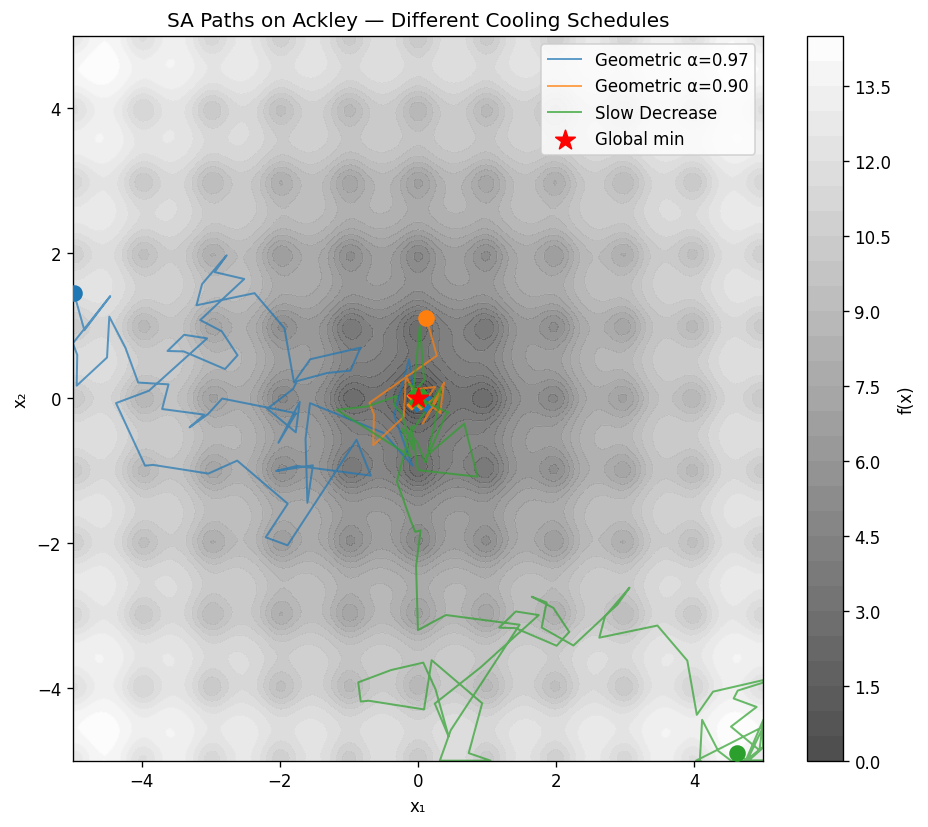

In [7]:
fig = plot_path_on_contour(
    ackley, ackley_bounds, results_by_schedule,
    title='SA Paths on Ackley — Different Cooling Schedules',
    known_minimum=[0, 0], levels=30, cmap='gray'
)
plt.show()

## 3  Acceptance Probability Over Time

Watching the acceptance probability gives insight into the exploration-exploitation balance.

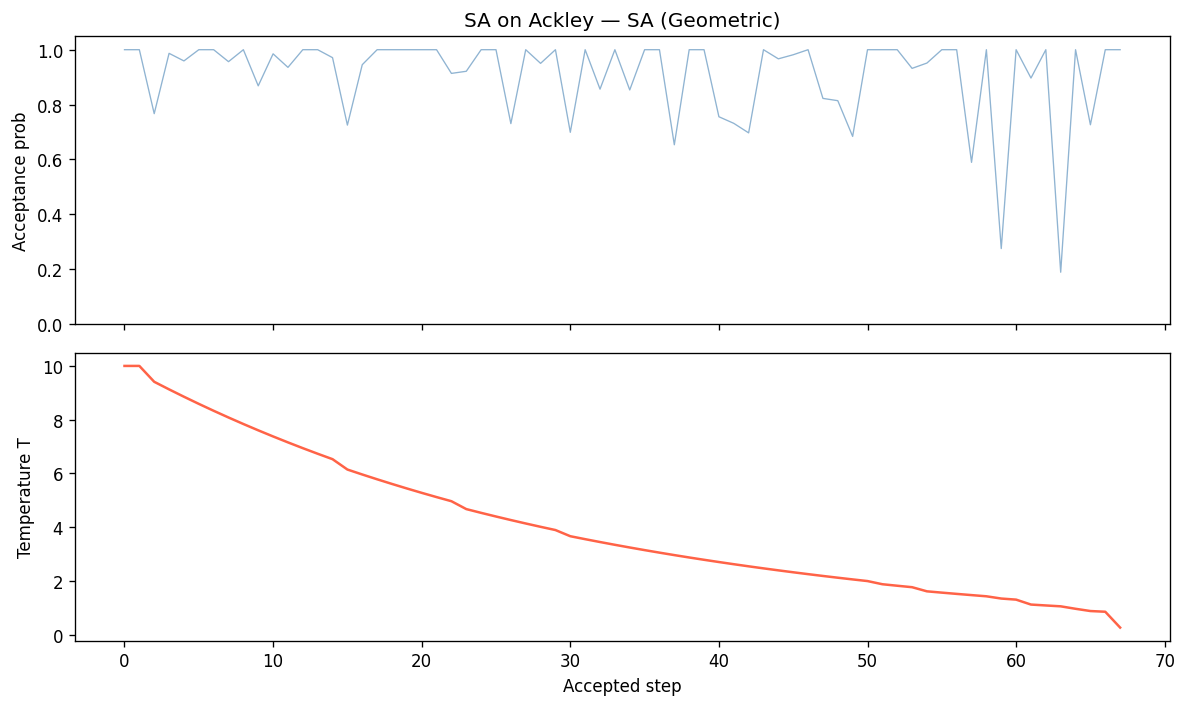

Average acceptance probability: 0.907
Fraction of steps that were improvements: 0.515


In [8]:
sa_for_viz = SimulatedAnnealing(
    schedule=GeometricCooling(alpha=0.97),
    neighbourhood=GaussianStep(scale=0.5, seed=1),
    initial_temp=10.0,
    final_temp=1e-4,
)
r_viz = sa_for_viz.optimize(ackley, bounds=ackley_bounds)

fig = plot_acceptance_probability(r_viz, title='SA on Ackley', optimizer_name='SA (Geometric)')
plt.show()

print(f"Average acceptance probability: {np.mean(r_viz.acceptance_probs):.3f}")
print(f"Fraction of steps that were improvements: {sum(p == 1.0 for p in r_viz.acceptance_probs) / len(r_viz.acceptance_probs):.3f}")

## 4  Classical SA vs. Stochastic SA (Reheating)

Stochastic SA (SSA) adds a **reheating** mechanism: when the search stagnates for `patience` steps without improvement, the temperature is spiked back up.  This lets the algorithm escape deep local basins.

In [9]:
# Run 10 independent trials of each and compare results on Ackley
n_trials = 10
sa_values, ssa_values = [], []

for seed in range(n_trials):
    sa = SimulatedAnnealing(
        schedule=GeometricCooling(alpha=0.97),
        neighbourhood=GaussianStep(scale=0.5, seed=seed),
        initial_temp=10.0,
        final_temp=1e-4,
    )
    ssa = StochasticSA(
        schedule=GeometricCooling(alpha=0.97),
        neighbourhood=GaussianStep(scale=0.5, seed=seed),
        initial_temp=10.0,
        final_temp=1e-4,
        patience=30,
        reheat_factor=2.5,
        max_reheats=5,
    )
    sa_values.append(sa.optimize(ackley, bounds=ackley_bounds).value)
    ssa_values.append(ssa.optimize(ackley, bounds=ackley_bounds).value)

print(f"Classical SA  — mean: {np.mean(sa_values):.4f}  std: {np.std(sa_values):.4f}  best: {min(sa_values):.4f}")
print(f"Stochastic SA — mean: {np.mean(ssa_values):.4f}  std: {np.std(ssa_values):.4f}  best: {min(ssa_values):.4f}")

Classical SA  — mean: 0.1306  std: 0.0690  best: 0.0235
Stochastic SA — mean: 0.9558  std: 1.8217  best: 0.0395


/var/folders/3x/1glgdfln2yq8vrrfnclf6n_w0000gn/T/ipykernel_44038/2474527667.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sa_values, ssa_values], labels=['Classical SA', 'Stochastic SA (reheating)'])


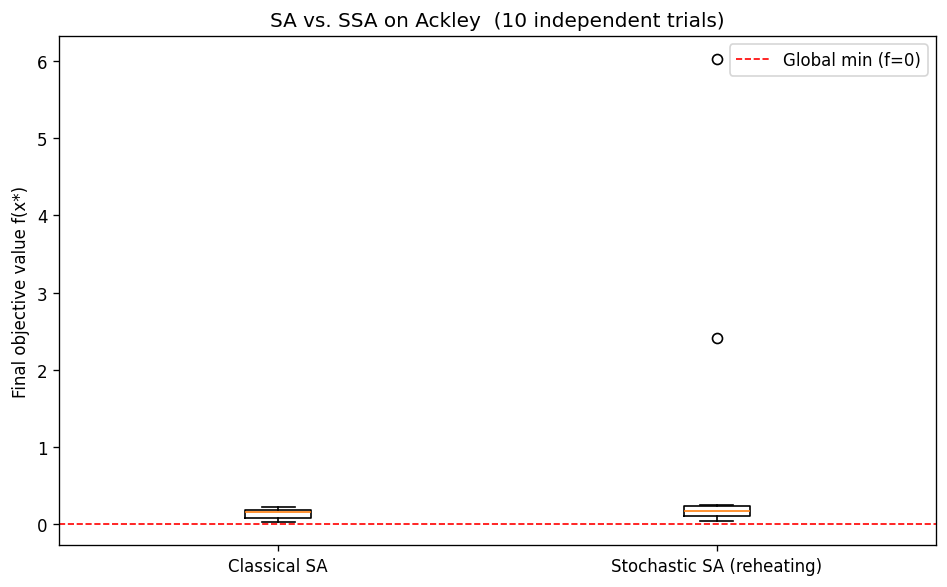

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([sa_values, ssa_values], labels=['Classical SA', 'Stochastic SA (reheating)'])
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Global min (f=0)')
ax.set_ylabel('Final objective value f(x*)')
ax.set_title(f'SA vs. SSA on Ackley  ({n_trials} independent trials)')
ax.legend()
plt.tight_layout()
plt.show()

## 5  Temperature Sensitivity

What happens when we choose **T_initial** poorly?

T_initial =    0.1  →  f* = 0.2653
T_initial =    1.0  →  f* = 0.1141
T_initial =    5.0  →  f* = 0.2202
T_initial =   10.0  →  f* = 0.2469
T_initial =   50.0  →  f* = 0.0476
T_initial =  200.0  →  f* = 0.0205


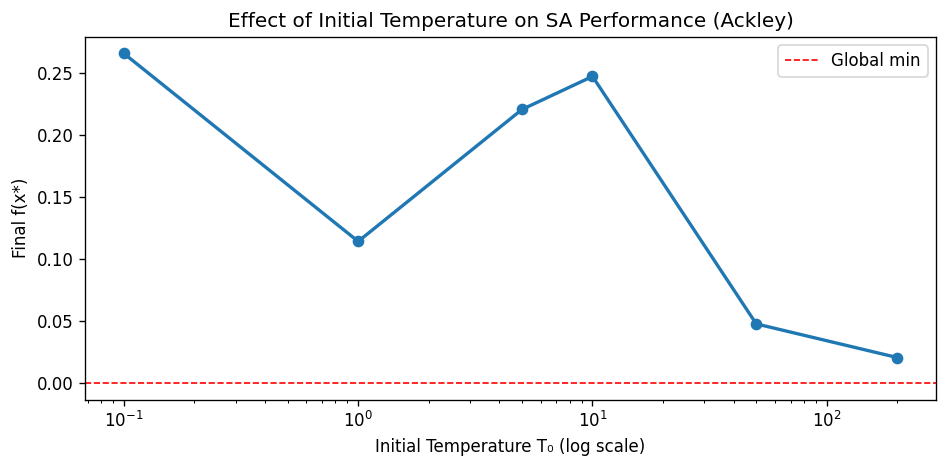

In [11]:
initial_temps = [0.1, 1.0, 5.0, 10.0, 50.0, 200.0]
temp_results = {}

for T0 in initial_temps:
    sa = SimulatedAnnealing(
        schedule=GeometricCooling(alpha=0.97),
        neighbourhood=GaussianStep(scale=0.5, seed=0),
        initial_temp=T0,
        final_temp=1e-4,
    )
    r = sa.optimize(ackley, bounds=ackley_bounds)
    temp_results[T0] = r.value
    print(f"T_initial = {T0:6.1f}  →  f* = {r.value:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(list(temp_results.keys()), list(temp_results.values()), 'o-', linewidth=2)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Global min')
ax.set_xlabel('Initial Temperature T₀ (log scale)')
ax.set_ylabel('Final f(x*)')
ax.set_title('Effect of Initial Temperature on SA Performance (Ackley)')
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**

- **T_initial too low** → algorithm behaves like greedy hill-climbing; gets trapped immediately.
- **T_initial too high** → algorithm wanders randomly; wastes evaluations before meaningful cooling begins.
- **Sweet spot** → high enough that early acceptance rate ≈ 80%, low enough that the budget isn't wasted.

A practical rule of thumb: set T_initial so that the acceptance rate of an average worsening move is 0.8–0.9.

## Summary

| Insight | Detail |
|---|---|
| Path tracing reveals behaviour | SA explores broadly early, then converges |
| Schedule choice matters | Slow cooling (α=0.97) outperforms fast (α=0.90) on multimodal |
| Reheating helps on Ackley | SSA reduces variance and finds better minima |
| Temperature sensitivity | T_initial must be calibrated to the landscape scale |

➡ **Next:** [04_comparison.ipynb](04_comparison.ipynb) — benchmarking SA against Gradient Descent and Random Search.